<a href="https://colab.research.google.com/github/xy-cs/H2_Computing/blob/main/TYS/2025%20Alevel%20Paper%202/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 2**

Name your Jupyter Notebook as:

`TASK2_<your name>_<centre number>_<index number>.ipynb`

A prototype for a computer game needs to be created using Object-Oriented Programming.

The game has a player who has to move through a series of rooms. Each room has at least one door to one other room. In all rooms apart from the Start room, a user has to answer a question correctly before he can move to the room he has chosen.

An example layout for a series of rooms is shown. This layout is an example and does **not** match the layout for the game you will be programming.

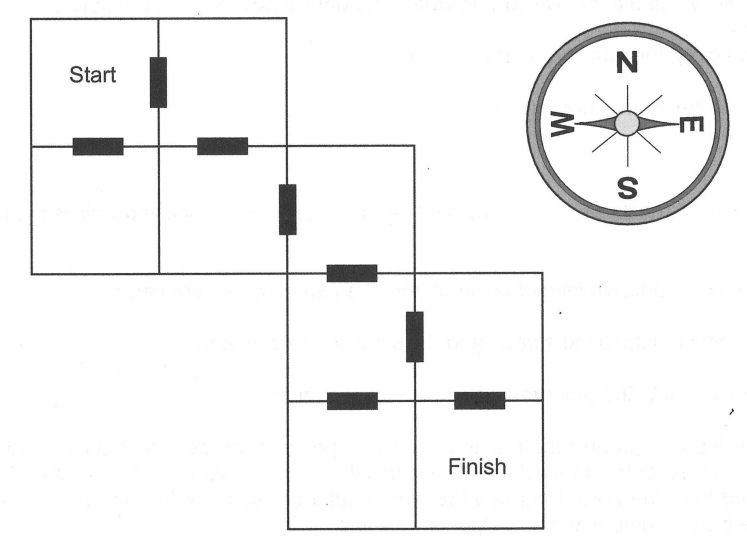

Each room has four positions where a door can be situated: North, South, East and West. Not all rooms have a door in each position. In the example diagram, each room is represented by a square and each door is represented by a solid rectangle between the two rooms. For example, the Start room only has doors to the East and the South.

Each room is given a number; the Start room is room number 0.

For each of the sub-tasks, add a comment statement at the beginning of the code, using the hash symbol '#', to indicate the sub-task the program code belongs to, for example:

```
In [1]: #Task 2.1
        Program code

        Output:
```


**Task 2.1**

The class `Room` contains four attributes:

- `north_exit` – an integer for the room number that the North door leads to, or −1 if there is no door.
- `east_exit` – an integer for the room number that the East door leads to, or −1 if there is no door.
- `south_exit` – an integer for the room number that the South door leads to, or −1 if there is no door.
- `west_exit` – an integer for the room number that the West door leads to, or −1 if there is no door.

The class `Room` has the following methods:

- A constructor that takes four integers for `north_exit`, `east_exit`, `south_exit` and `west_exit` as parameters. Each parameter is assigned to the appropriate attribute.
- `get_exit()` that takes a character as a parameter (`'N'`, `'S'`, `'E'`, or `'W'`) to represent the door selected and returns the attribute value for that door.

Write program code to declare the class `Room` and its methods. **[5]**

Three classes inherit from `Room`: `Start`, `Finish` and `Normal`

`Start` is the first room where the game begins and also contains:

- the attribute `start_text` that is output at the beginning of the game. This value is initialised in the constructor from a parameter
- the method `get_message()` that returns the string in `start_text` and a statement for each direction where there is a door from that room, for example 'There is a door to the North.' The method also returns the string `"Start"` (for example as part of a tuple) to indicate that this is the Start room.

Write program code to declare the class `Start` and its methods. **[5]**

`Finish` is the room where the game ends and also contains:

- the attribute `finish_text` that is output at the end of the game. This value is initialised in the constructor from a parameter
- the method `get_message()` that returns `finish_text` and the string `"Finish"` (for example as part of a tuple) to indicate that the game is finished.

Write program code to declare the class `Finish` and its methods. **[2]**

`Normal` is a room that is **not** the Start room and is **not** the Finish room. The class `Normal` also contains:

- the attributes `question` and `answer`. The value of each is initialised in the constructor from its parameter
- the method `get_question()` that returns the data in `question`
- the method `check_answer()` that compares its parameter (the user's answer) to `answer` and returns `True` if it matches and `False` if it does **not** match
- the method `get_message()` that returns a string describing all of the doors from that room, for example 'There is a room to the North. There is a room to the West.' The method also returns the string `"Normal"` (for example as part of a tuple) to indicate that this is a normal room.

Write program code to declare the class `Normal` and its methods. **[4]**


In [ ]:
#Task 2.1
class Room():
  def __init__(self, north_exit, east_exit, south_exit, west_exit):
    self.north_exit = north_exit
    self.east_exit = east_exit
    self.south_exit = south_exit
    self.west_exit  = west_exit
  def get_exit(self, exit):
    if exit == 'N':
      return self.north_exit
    if exit == 'S':
      return self.south_exit
    if exit == 'E':
      return self.east_exit
    if exit == 'W':
      return self.west_exit

class Start(Room):
  def __init__(self, north_exit, east_exit, south_exit, west_exit, start_text):
    super().__init__(north_exit, east_exit, south_exit, west_exit)
    self.start_text = start_text
  def get_message(self):
    exit = ['N', 'S', 'E', 'W']
    statement = [self.start_text, 'Start']
    direction = ['North', 'South', 'East', 'West']
    count = 0
    for i in exit:
      valid = self.get_exit(i)
      if valid != -1:
        direc = "There is a door to the "+direction[count]
        statement.append(direc)
      count += 1
    string = ""
    for i in statement:
      string += i + '\n'
    return string

class Finish(Room):
  def __init__(self, finish_text):
    self.finish_text = finish_text
  def get_message(self):
    return "Finish", self.finish_text

class Normal(Room):
  def __init__(self, north_exit, east_exit, south_exit, west_exit, question, answer):
    super().__init__(north_exit, east_exit, south_exit, west_exit)
    self.question = question
    self.answer = answer

  def get_question(self):
    return self.question

  def check_answer(self, user_ans):
    if user_ans == str(self.answer):
      return True
    else:
      return False

  def get_message(self):
    exit = ['N', 'S', 'E', 'W']
    statement = ['Normal']
    direction = ['North', 'South', 'East', 'West']
    count = 0
    for i in exit:
      valid = self.get_exit(i)
      if valid != -1:
        direc = "There is a door to the "+direction[count]
        statement.append(direc)
      count += 1
    string = ""
    for i in statement:
      string += i + '\n'
    return string

**Task 2.2**

The text file `rooms.txt` stores data about the rooms in the game. Each row of data is a separate room.

The values in each row are in the order:

- room type: Start, Finish or Normal
- the room number that can be accessed to the North of the room, or −1 if there is no door
- the room number that can be accessed to the East of the room, or −1 if there is no door
- the room number that can be accessed to the South of the room, or −1 if there is no door
- the room number that can be accessed to the West of the room, or −1 if there is no door
- the start message if the room is of type `Start`
  or the finish message if the room is of type `Finish`
  or the question if the room is of type `Normal`
- the answer to the question if the room is of type `Normal`

The rooms are read in the order they appear in the file and stored in a 1-dimensional list. For example: the room in the first row of the file is stored in index 0; the room in the second row of the file is stored in index 1.

Write program code for a function to:

- read the data from the text file
- create an object of the appropriate class for each room
- store the rooms in a 1-dimensional list
- return the 1-dimensional list.

**[7]**


In [ ]:
#Task 2.2
with open ('rooms.txt', 'r') as file:
  file = file.readlines()
  #file closes automatically
  rooms = []
for i in range(len(file)):
  file[i] = file[i].strip('\n').split(',')
  if file[i][0] == "Start":
    room = Start(int(file[i][1]), int(file[i][2]), int(file[i][3]), int(file[i][4]), file[i][5])
    #room = room.__dict__
  if file[i][0] == "Finish":
    room = Finish(file[i][5])
  if file[i][0] == "Normal":
    room = Normal(int(file[i][1]), int(file[i][2]), int(file[i][3]), int(file[i][4]), file[i][5], file[i][6])
  rooms.append(room)
print(rooms)

[<__main__.Start object at 0x7c0fb4513e00>, <__main__.Normal object at 0x7c0fb5e95010>, <__main__.Normal object at 0x7c0fb49c4380>, <__main__.Normal object at 0x7c0fb5f041a0>, <__main__.Normal object at 0x7c0fb5e75910>, <__main__.Normal object at 0x7c0fa7fa2300>, <__main__.Normal object at 0x7c0fb40b3830>, <__main__.Normal object at 0x7c0fa7da2540>, <__main__.Normal object at 0x7c0fa7da3560>, <__main__.Normal object at 0x7c0fa7da1790>, <__main__.Normal object at 0x7c0fa7da1970>, <__main__.Normal object at 0x7c0fa7da3890>, <__main__.Normal object at 0x7c0fa7da3140>, <__main__.Finish object at 0x7c0fa7da0f80>]


**Task 2.3**

When the game is played, the message in the Start room is output which includes the position of the door(s).

The user inputs the door to go through until he provides a valid door. The message for the new room is output which includes the position of the door(s) in that room. When the user selects a door, the question for the room he is in is output. The user needs to enter his answer until he provides the correct answer.

The process repeats until the user reaches the Finish room. When the user reaches the Finish room, the message for the room is output and the game ends.

Write program code for a function to allow a user to play the game and call this function. **[13]**

Test your program with the following inputs:

```
input 1:  N
input 2:  E
input 3:  00
input 4:  FF
input 5:  N
input 6:  0
input 7:  N
input 8:  170
input 9:  E
input 10: 0
input 11: N
input 12: 2
input 13: E
input 14: 4
```

**[2]**

Save your Jupyter Notebook for Task 2.


In [ ]:
#Task 2.3
def play_game():
  print(rooms[0].get_message())
  while True:
    exit = input("Enter room to enter: ")
    room = rooms[0].get_exit(exit)
    valid = [rooms[0].north_exit, rooms[0].south_exit, rooms[0].east_exit, rooms[0].west_exit]
  #print(valid)
    if room in valid:
        break
  while True:
    if rooms[int(room)].get_message() == rooms[-1].get_message():
      rooms[-1].get_message()
      break
    print(rooms[int(room)].get_question())
    while True:
      answer = input("Enter answer: ")
      if rooms[int(room)].check_answer(answer) == True:
        print(rooms[int(room)].get_message())
        break
    while True:
        exit = input("Enter room to enter: ")
        room = rooms[0].get_exit(exit)
        if rooms[int(room)].get_message() == rooms[-1].get_message():
          print(rooms[-1].get_message())
          break
        valid = [rooms[int(room)].north_exit, rooms[int(room)].south_exit, rooms[int(room)].east_exit, rooms[int(room)].west_exit]
        if room in valid:
            break

#main
play_game()

Welcome to the room game. Are you ready to begin?
Start
There is a door to the North
There is a door to the East

Enter room to enter: N
What is the largest 2-digit hexadecimal number?
Enter answer: FF
Normal
There is a door to the South
There is a door to the East

Enter room to enter: S
('Finish', 'Congratulations on escaping the room game')
